# Exploratory Data Analysis (EDA)

This notebook performs an exploratory data analysis of the aerodynamic dataset generated using XFOIL for NACA 4-digit airfoils.

The objectives are:

- Understand the structure and quality of the dataset.
- Verify that the aerodynamic trends are physically meaningful.
- Identify anomalies and potential outliers.
- Gain insights into relationships between airfoil geometry, operating conditions, and aerodynamic coefficients.
- Inform preprocessing decisions before training the neural network surrogate model.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# For reproducibility
np.random.seed(42)

In [6]:
# Load Dataset

from google.colab import files

uploaded = files.upload()


Saving dataset.csv to dataset (1).csv


In [7]:
df = pd.read_csv("dataset.csv")

df.head()

,Camber,Position,Thickness,Re,Alpha,CL,CD,CDp,CM,TopXtr,BotXtr
0,0,1,8,50000,-5.0,-0.5521,0.02602,0.01471,-0.0061,1.0,0.1854
1,0,1,8,50000,-4.5,-0.5035,0.02193,0.01124,-0.0037,1.0,0.2831
2,0,1,8,50000,-4.0,-0.4782,0.01831,0.00981,0.0050,1.0,0.6039
3,0,1,8,50000,-3.5,-0.4421,0.01849,0.01042,0.0171,1.0,0.8180
4,0,1,8,50000,-3.0,-0.2327,0.01964,0.01008,-0.0049,1.0,0.9825


In [8]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
df.info()
df.describe().T
df.head()
df.tail()

Rows    : 599,869
Columns : 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599869 entries, 0 to 599868
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Camber     599869 non-null  int64  
 1   Position   599869 non-null  int64  
 2   Thickness  599869 non-null  int64  
 3   Re         599869 non-null  int64  
 4   Alpha      599869 non-null  float64
 5   CL         599869 non-null  float64
 6   CD         599869 non-null  float64
 7   CDp        599869 non-null  float64
 8   CM         599869 non-null  float64
 9   TopXtr     599869 non-null  float64
 10  BotXtr     599869 non-null  float64
dtypes: float64(7), int64(4)
memory usage: 50.3 MB


,Camber,Position,Thickness,Re,Alpha,CL,CD,CDp,CM,TopXtr,BotXtr
599864,8,8,24,2000000,21.0,2.0734,0.11898,0.11427,-0.1708,0.0901,0.7760
599865,8,8,24,2000000,22.0,2.0632,0.13042,0.12586,-0.1701,0.0816,0.7811
599866,8,8,24,2000000,23.0,2.0529,0.14203,0.13763,-0.1713,0.0744,0.7856
599867,8,8,24,2000000,24.0,2.0472,0.15303,0.14875,-0.1738,0.0678,0.7894
599868,8,8,24,2000000,25.0,2.0356,0.16480,0.16069,-0.1781,0.0618,0.7927


In [9]:
#data quality assesment
missing=df.isnull().sum()
print(missing)

duplicates=df.duplicated().sum()
print(duplicates)

df.nunique()

df.agg(["min","max"]).T

Camber       0
Position     0
Thickness    0
Re           0
Alpha        0
CL           0
CD           0
CDp          0
CM           0
TopXtr       0
BotXtr       0
dtype: int64
183635


,min,max
Camber,0.00000,8.000000e+00
Position,1.00000,8.000000e+00
Thickness,8.00000,2.400000e+01
Re,50000.00000,2.000000e+06
Alpha,-5.00000,2.500000e+01
CL,-0.85250,2.228600e+00
CD,0.00058,3.591300e-01
CDp,-0.00630,3.582100e-01
CM,-0.35880,6.480000e-02
TopXtr,0.00000,1.000000e+00


## Removing Duplicate Records

During dataset generation, the simulation process was restarted after a file access issue while appending new operating points. As a result, duplicate rows were introduced into the raw dataset.

Duplicate records are removed before further analysis to ensure that each aerodynamic operating point is represented only once.

In [29]:
df = df.drop_duplicates()
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
df.to_csv("cleaned_dataset.csv", index=False)
df = pd.read_csv("cleaned_dataset.csv")

Rows    : 416,234
Columns : 11


In [30]:
#physics validation
def plot_airfoil(camber, position, thickness, reynolds):

    airfoil = df[
        (df["Camber"] == camber) &
        (df["Position"] == position) &
        (df["Thickness"] == thickness) &
        (df["Re"] == reynolds)
    ].sort_values("Alpha")

    if airfoil.empty:
        print("No matching airfoil found.")
        return

    fig, axs = plt.subplots(2, 2, figsize=(12,7))

    # CL
    axs[0,0].plot(
        airfoil["Alpha"],
        airfoil["CL"],
        marker='o'
    )

    axs[0,0].set_title("Lift Coefficient")
    axs[0,0].set_xlabel("Angle of Attack (deg)")
    axs[0,0].set_ylabel("CL")
    axs[0,0].grid(True)

    # CD
    axs[0,1].plot(
        airfoil["Alpha"],
        airfoil["CD"],
        marker='o',
        color='red'
    )

    axs[0,1].set_title("Drag Coefficient")
    axs[0,1].set_xlabel("Angle of Attack (deg)")
    axs[0,1].set_ylabel("CD")
    axs[0,1].grid(True)

    # CM
    axs[1,0].plot(
        airfoil["Alpha"],
        airfoil["CM"],
        marker='o',
        color='green'
    )

    axs[1,0].set_title("Moment Coefficient")
    axs[1,0].set_xlabel("Angle of Attack (deg)")
    axs[1,0].set_ylabel("CM")
    axs[1,0].grid(True)

    # Transition
    axs[1,1].plot(
        airfoil["Alpha"],
        airfoil["TopXtr"],
        marker='o',
        label="Top Surface"
    )

    axs[1,1].plot(
        airfoil["Alpha"],
        airfoil["BotXtr"],
        marker='s',
        label="Bottom Surface"
    )

    axs[1,1].set_title("Transition Location")
    axs[1,1].set_xlabel("Angle of Attack (deg)")
    axs[1,1].set_ylabel("x/c")
    axs[1,1].legend()
    axs[1,1].grid(True)

    plt.suptitle(
        f"NACA {camber}{position}{thickness:02d}   Re = {reynolds:,}",
        fontsize=16
    )

    plt.tight_layout()

    plt.show()

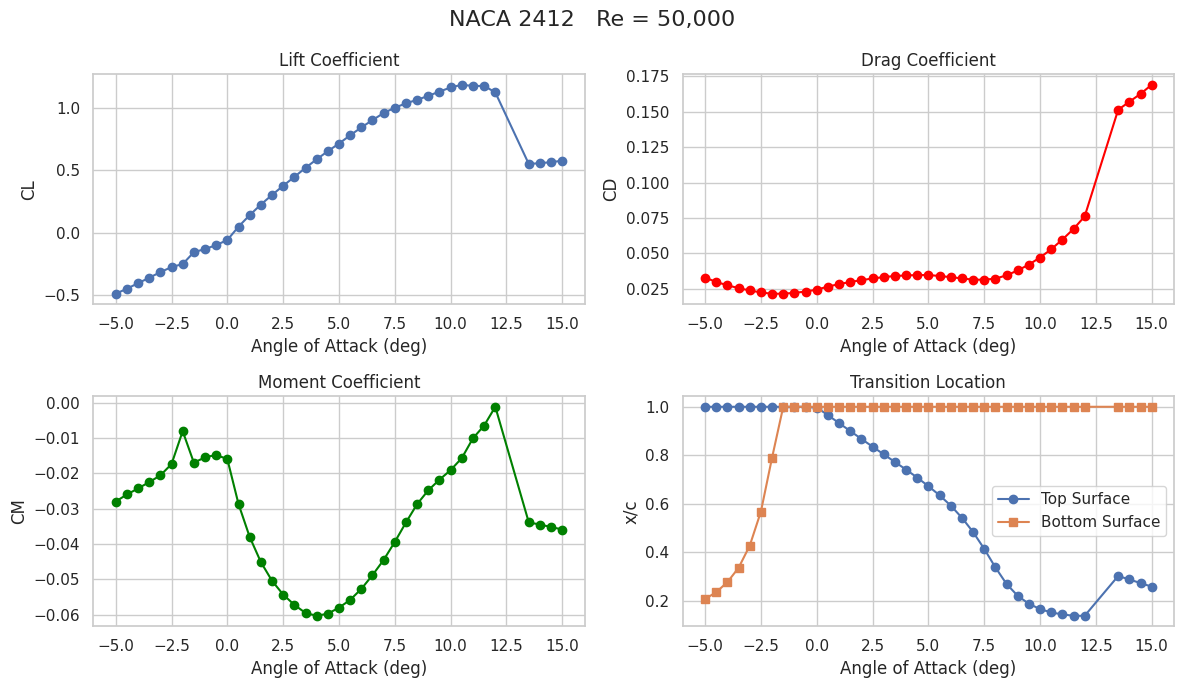

In [31]:
plot_airfoil(
    camber=2,
    position=4,
    thickness=12,
    reynolds=50000
)

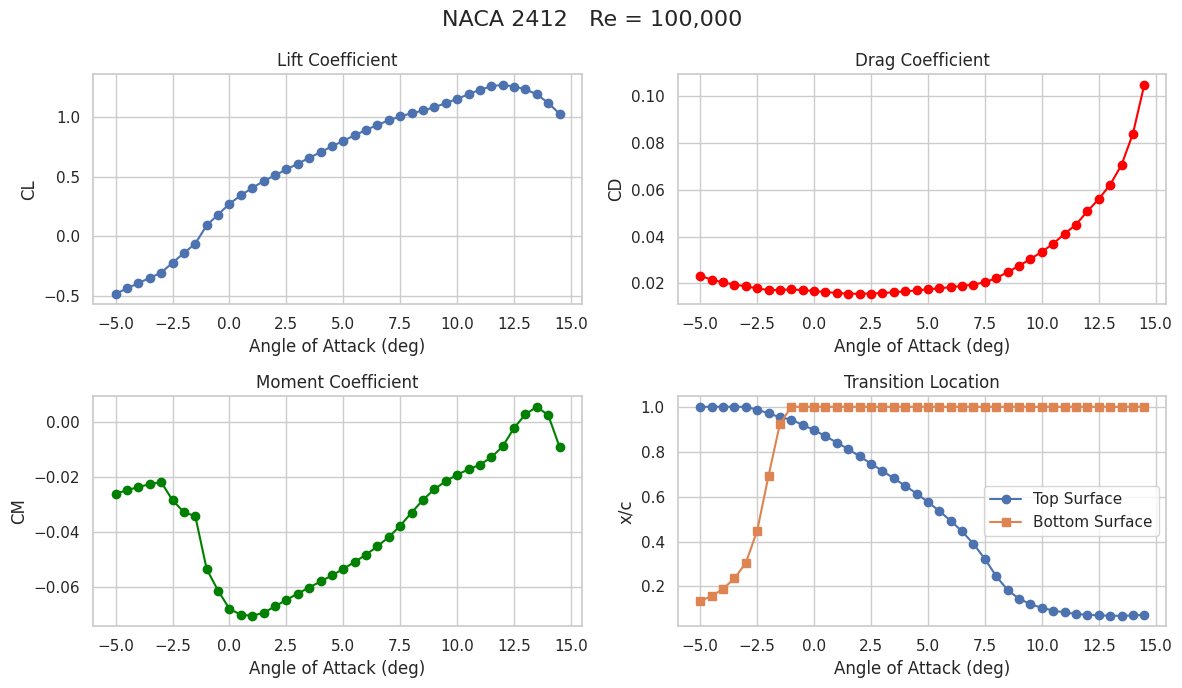

In [32]:
plot_airfoil(
    camber=2,
    position=4,
    thickness=12,
    reynolds=100000
)

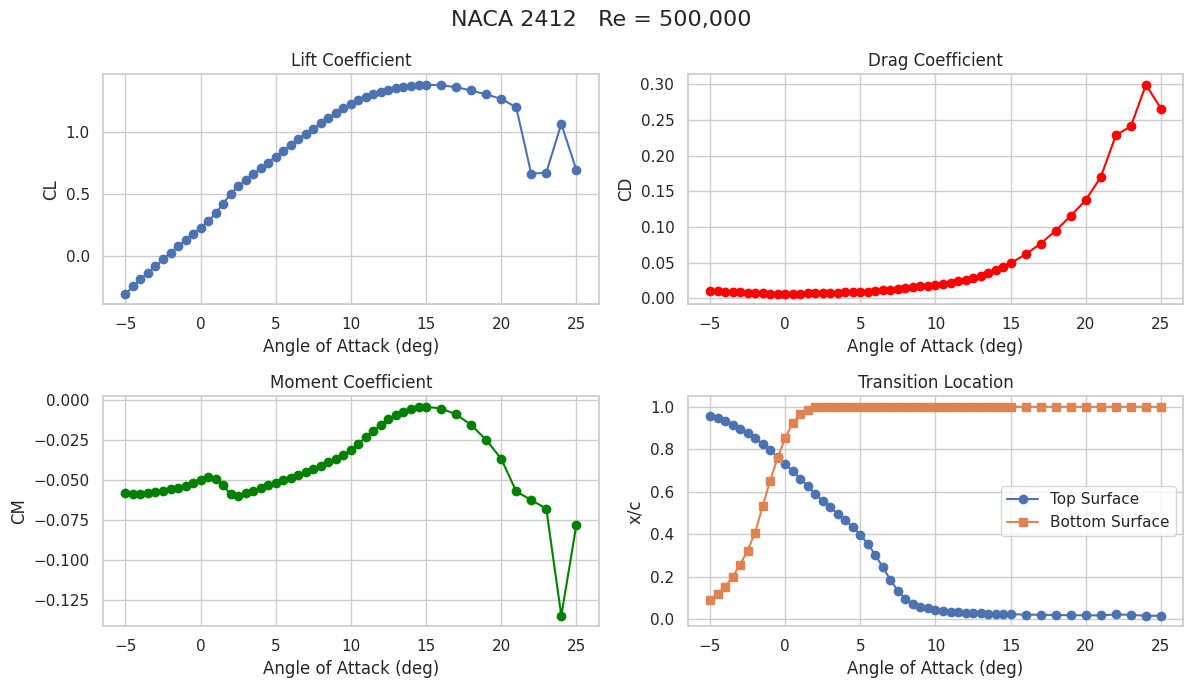

In [33]:
plot_airfoil(
    camber=2,
    position=4,
    thickness=12,
    reynolds=500000
)

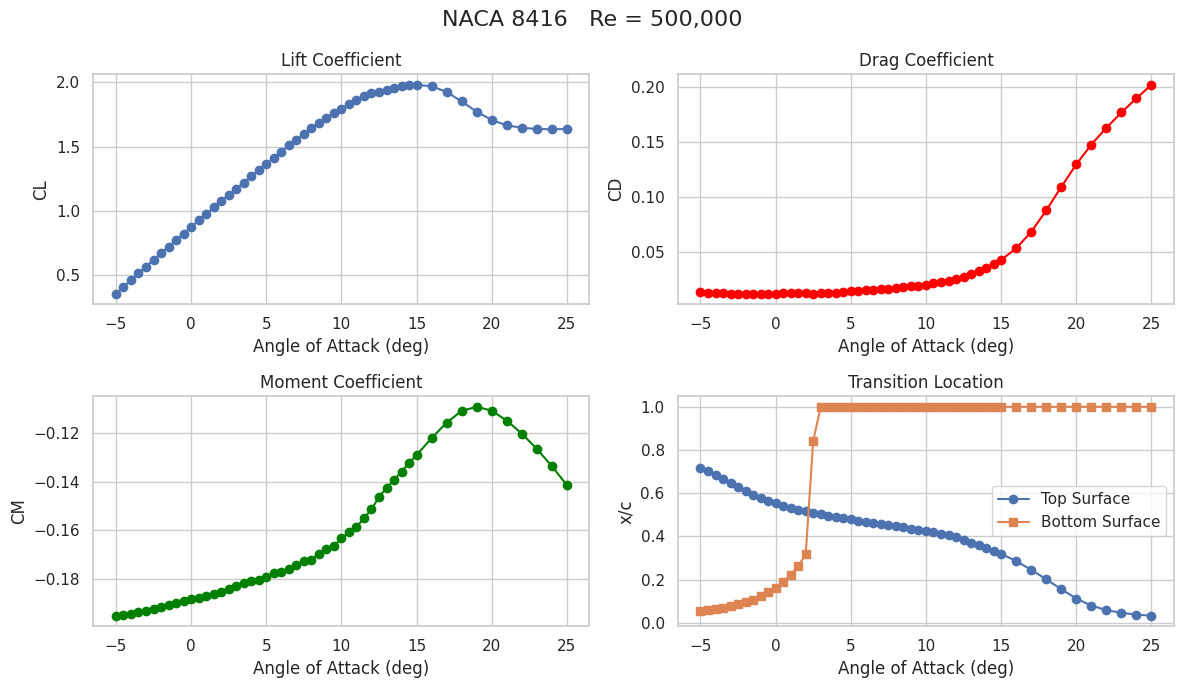

In [34]:
plot_airfoil(
    camber=8,
    position=4,
    thickness=16,
    reynolds=500000
)

# 6. Distribution Analysis

Understanding the distribution of the aerodynamic coefficients is essential before training a machine learning model.

This section examines the global distributions of:

- Lift Coefficient (CL)
- Drag Coefficient (CD)
- Pitching Moment Coefficient (CM)
- Lift-to-Drag Ratio (L/D)

The objective is to identify:

- Distribution shape
- Skewness
- Potential outliers
- Physically unrealistic values

In [35]:
df["L_D"] = df["CL"] / df["CD"]

In [36]:
distribution_columns = ["CL", "CD", "CM", "L_D"]

df[distribution_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CL,416234.0,0.902749,0.614455,-0.852500,0.440800,0.992000,1.404075,2.228600
CD,416234.0,0.035220,0.043387,0.000580,0.011270,0.019300,0.036990,0.359130
CM,416234.0,-0.079173,0.070399,-0.358800,-0.125000,-0.069100,-0.023300,0.064800
L_D,416234.0,43.156131,42.793758,-155.928144,14.706501,40.533109,65.571739,1188.252427


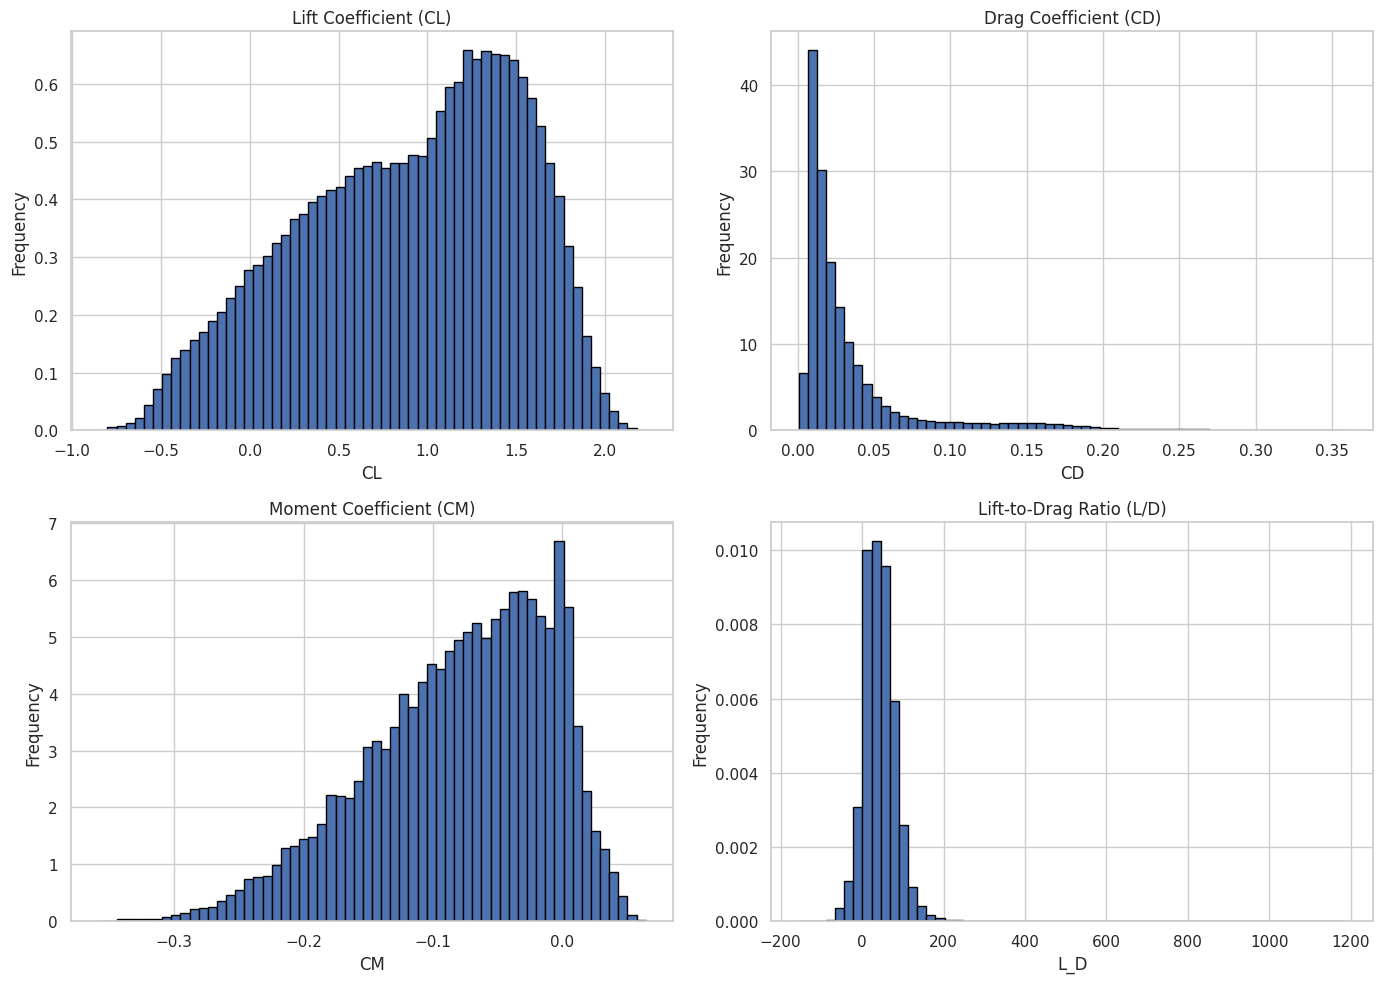

In [43]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

columns = ["CL", "CD", "CM", "L_D"]
titles = [
    "Lift Coefficient (CL)",
    "Drag Coefficient (CD)",
    "Moment Coefficient (CM)",
    "Lift-to-Drag Ratio (L/D)"
]

for ax, column, title in zip(axs.flatten(), columns, titles):

    ax.hist(
        df[column],
        bins=60,
        edgecolor='black',
        density='true'
    )

    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()

plt.show()

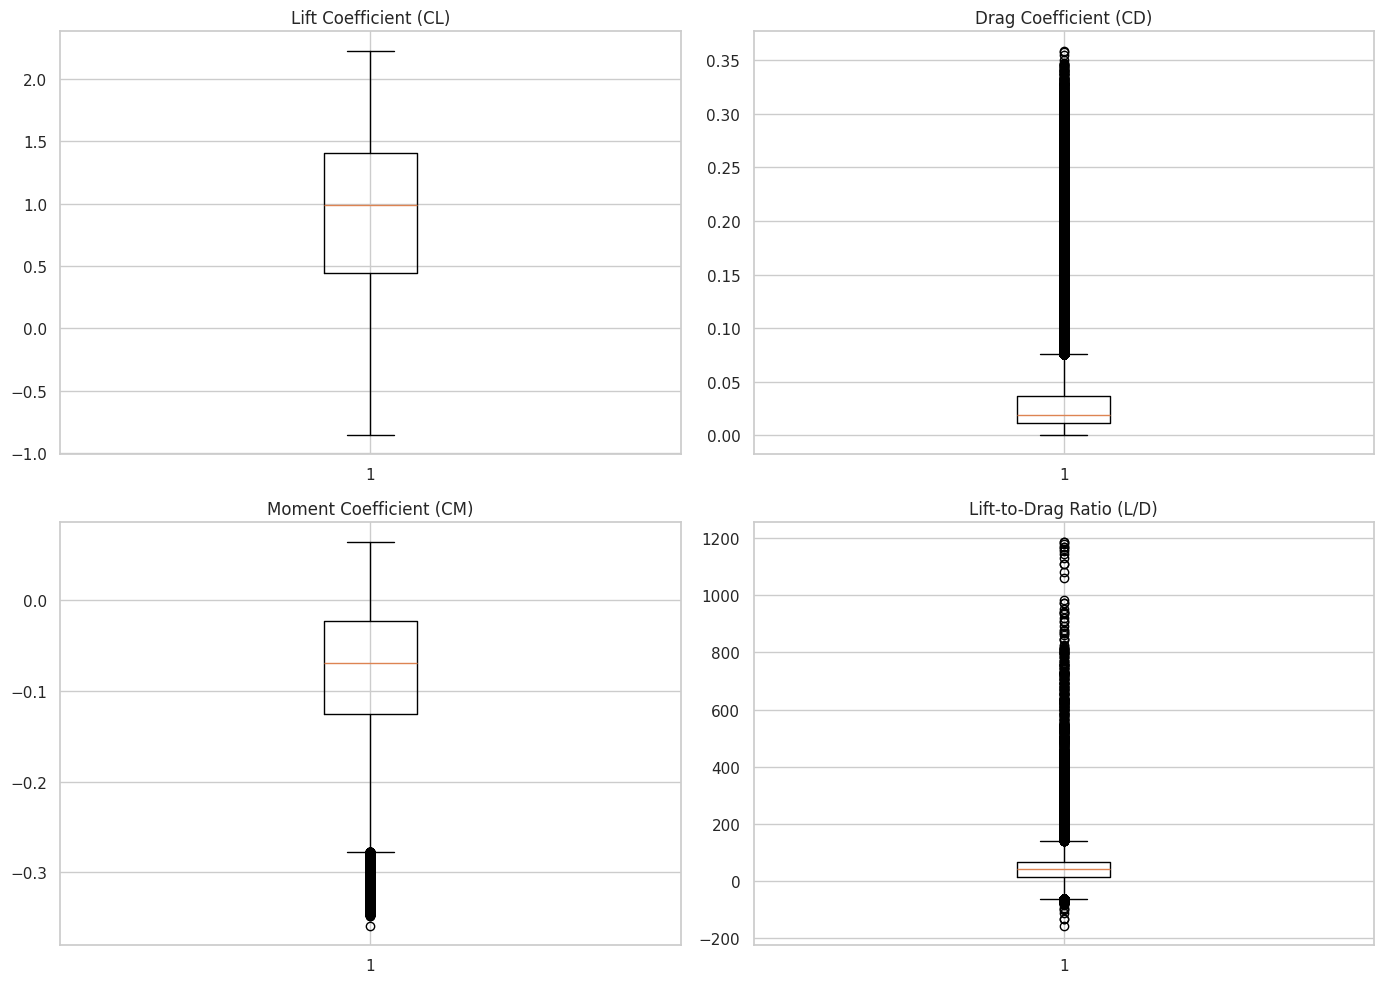

In [38]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

for ax, column, title in zip(axs.flatten(), columns, titles):

    ax.boxplot(df[column], vert=True)

    ax.set_title(title)

plt.tight_layout()

plt.show()

In [44]:
df[distribution_columns].skew()

,0
CL,-0.385178
CD,2.767358
CM,-0.623430
L_D,3.321977


In [45]:
df[distribution_columns].kurtosis()

,0
CL,-0.759351
CD,8.459798
CM,-0.122807
L_D,48.613784


Observations

1. CL exhibits a broad, approximately symmetric distribution, indicating good coverage of lifting conditions.
2. CD is strongly right-skewed, consistent with the presence of post-stall and high-drag operating points.
3. CM is predominantly negative, reflecting the prevalence of cambered airfoils.
4. L/D is concentrated within a practical operating range but includes a small number of exceptionally high values that will be investigated during the outlier analysis.

# 7. Correlation Analysis

A correlation matrix is used to quantify the linear relationship between the variables in the dataset.

Correlation coefficients range from:

- **+1** : Perfect positive correlation
- **0** : No linear correlation
- **−1** : Perfect negative correlation

Although correlation does not imply causation, it provides valuable insight into feature interactions and helps identify variables that may strongly influence the aerodynamic coefficients.

In [46]:
corr = df.corr(numeric_only=True)

corr

,Camber,Position,Thickness,Re,Alpha,CL,CD,CDp,CM,TopXtr,BotXtr,L_D
Camber,1.000000,0.048119,0.026519,0.009067,0.011969,0.359466,0.129402,0.125960,-0.793862,0.057577,-0.203070,0.195798
Position,0.048119,1.000000,-0.043857,0.009865,0.003543,0.077741,0.002253,0.007919,-0.396520,0.136592,0.021678,0.020777
Thickness,0.026519,-0.043857,1.000000,-0.004747,0.029554,0.006922,-0.037559,-0.043020,0.120697,0.008374,-0.067817,-0.093604
Re,0.009067,0.009865,-0.004747,1.000000,0.166736,0.213358,-0.039030,-0.016784,-0.080378,-0.285896,-0.049180,0.291477
Alpha,0.011969,0.003543,0.029554,0.166736,1.000000,0.824374,0.647667,0.651756,0.189780,-0.814668,0.737253,0.091070
CL,0.359466,0.077741,0.006922,0.213358,0.824374,1.000000,0.276112,0.280150,-0.190520,-0.751779,0.653318,0.425439
CD,0.129402,0.002253,-0.037559,-0.039030,0.647667,0.276112,1.000000,0.999356,0.016771,-0.352405,0.278961,-0.332432
CDp,0.125960,0.007919,-0.043020,-0.016784,0.651756,0.280150,0.999356,1.000000,0.012403,-0.353925,0.280211,-0.324167
CM,-0.793862,-0.396520,0.120697,-0.080378,0.189780,-0.190520,0.016771,0.012403,1.000000,-0.280466,0.286902,-0.279657
TopXtr,0.057577,0.136592,0.008374,-0.285896,-0.814668,-0.751779,-0.352405,-0.353925,-0.280466,1.000000,-0.613823,-0.239726


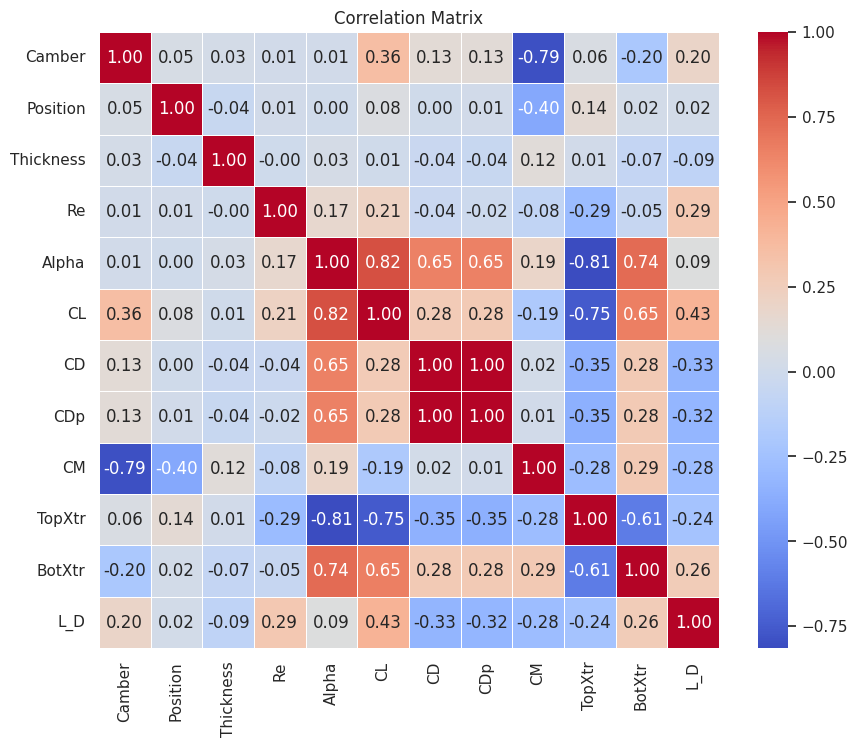

In [47]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

In [51]:
corr["CL"].sort_values(ascending=False)


,CL
CL,1.000000
Alpha,0.824374
BotXtr,0.653318
L_D,0.425439
Camber,0.359466
CDp,0.280150
CD,0.276112
Re,0.213358
Position,0.077741
Thickness,0.006922


In [52]:
corr["CD"].sort_values(ascending=False)


,CD
CD,1.000000
CDp,0.999356
Alpha,0.647667
BotXtr,0.278961
CL,0.276112
Camber,0.129402
CM,0.016771
Position,0.002253
Thickness,-0.037559
Re,-0.039030


In [53]:
corr["CM"].sort_values(ascending=False)

,CM
CM,1.000000
BotXtr,0.286902
Alpha,0.189780
Thickness,0.120697
CD,0.016771
CDp,0.012403
Re,-0.080378
CL,-0.190520
L_D,-0.279657
TopXtr,-0.280466


The correlation analysis demonstrates that the dataset captures the expected first-order aerodynamic relationships. Lift exhibits a strong positive correlation with angle of attack, drag is strongly associated with pressure drag and angle of attack, and pitching moment shows a strong negative correlation with camber. Variables such as thickness and camber position exhibit weaker linear correlations, suggesting that their influence is primarily nonlinear and dependent on interactions with other operating conditions. These findings support the use of a nonlinear surrogate model such as a neural network.

# 8. Relationship Analysis

Correlation coefficients quantify only linear relationships between variables. However, aerodynamic behaviour is highly nonlinear, particularly near stall.

This section visualizes the relationships between key aerodynamic parameters to better understand:

- Lift generation
- Drag growth
- Reynolds number effects
- Geometric influences
- Nonlinear aerodynamic trends

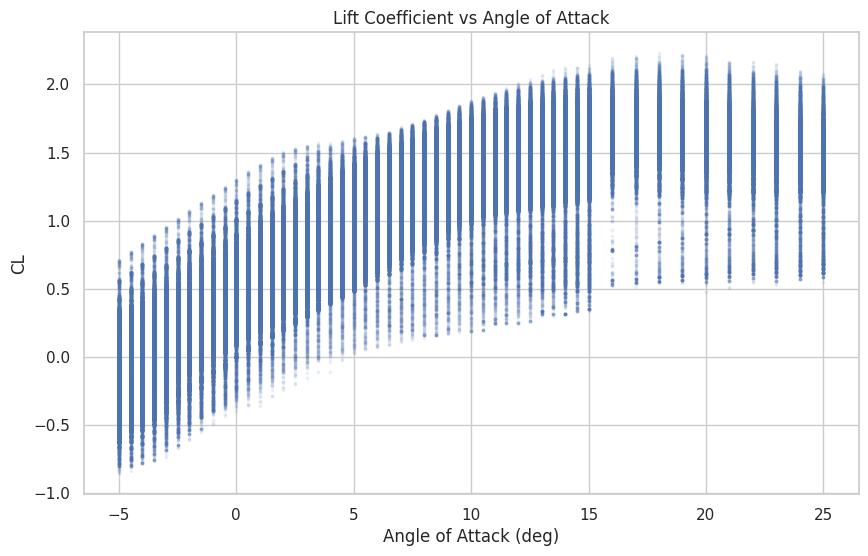

In [54]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Alpha"],
    df["CL"],
    s=3,
    alpha=0.08
)

plt.title("Lift Coefficient vs Angle of Attack")
plt.xlabel("Angle of Attack (deg)")
plt.ylabel("CL")

plt.grid(True)

plt.show()

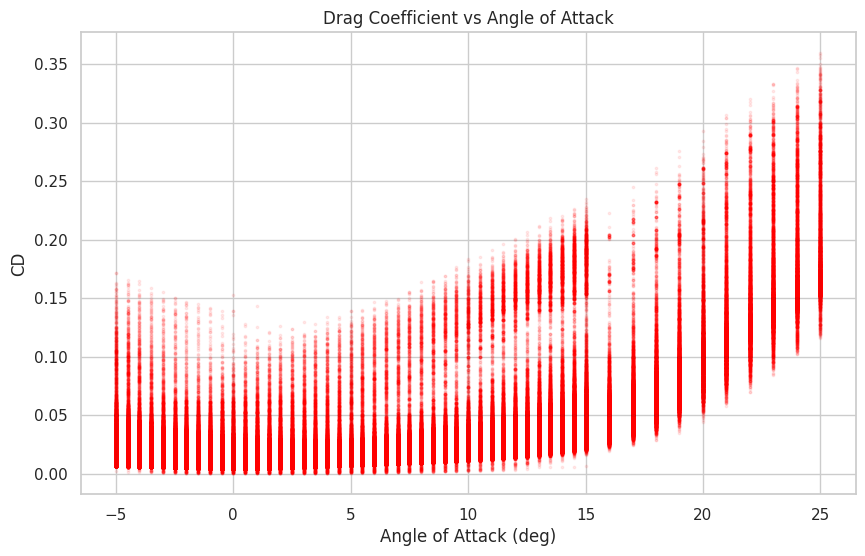

In [55]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Alpha"],
    df["CD"],
    s=3,
    alpha=0.08,
    color="red"
)

plt.title("Drag Coefficient vs Angle of Attack")
plt.xlabel("Angle of Attack (deg)")
plt.ylabel("CD")

plt.grid(True)

plt.show()


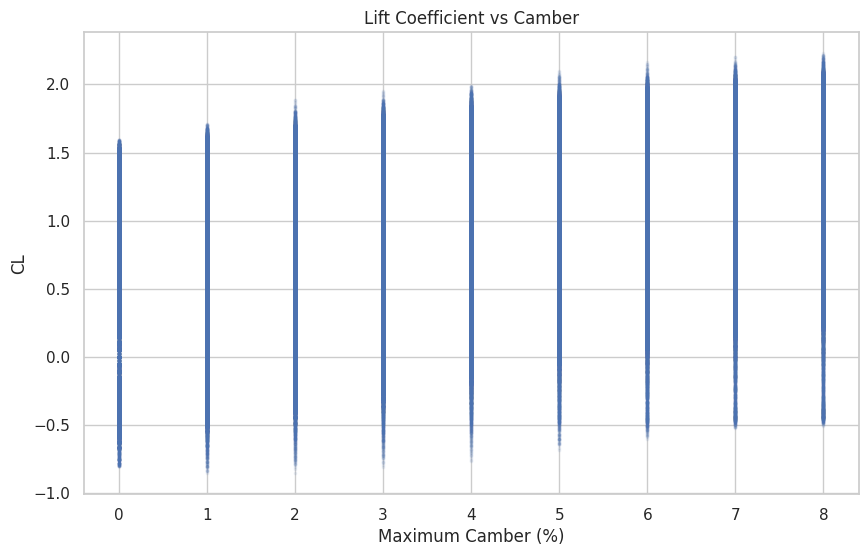

In [56]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Camber"],
    df["CL"],
    s=3,
    alpha=0.08
)

plt.title("Lift Coefficient vs Camber")
plt.xlabel("Maximum Camber (%)")
plt.ylabel("CL")

plt.grid(True)

plt.show()

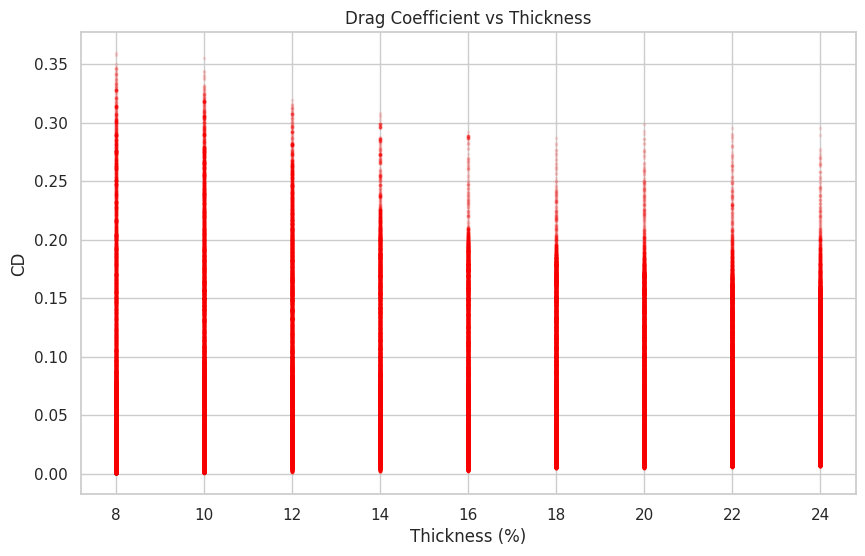

In [57]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Thickness"],
    df["CD"],
    s=3,
    alpha=0.08,
    color="red"
)

plt.title("Drag Coefficient vs Thickness")
plt.xlabel("Thickness (%)")
plt.ylabel("CD")

plt.grid(True)

plt.show()

In [60]:
# Mean CL vs Alpha
cl_alpha = (
    df.groupby("Alpha")["CL"]
      .mean()
      .reset_index()
)

# Mean CD vs Alpha
cd_alpha = (
    df.groupby("Alpha")["CD"]
      .mean()
      .reset_index()
)

# Mean CL vs Camber
cl_camber = (
    df.groupby("Camber")["CL"]
      .mean()
      .reset_index()
)

# Mean CD vs Thickness
cd_thickness = (
    df.groupby("Thickness")["CD"]
      .mean()
      .reset_index()
)

# Mean CL vs Reynolds Number
cl_re = (
    df.groupby("Re")["CL"]
      .mean()
      .reset_index()
)

# Mean CD vs Reynolds Number
cd_re = (
    df.groupby("Re")["CD"]
      .mean()
      .reset_index()
)

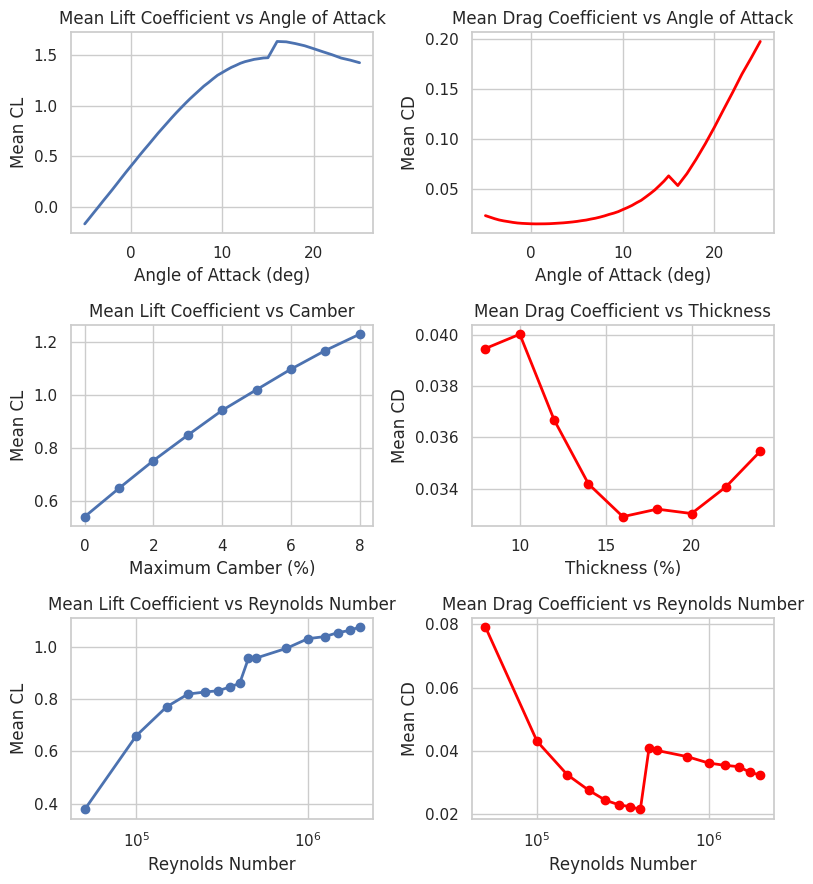

In [62]:
fig, axs = plt.subplots(3, 2, figsize=(8, 9))

# -------------------------------------------------------
# Mean CL vs Alpha
# -------------------------------------------------------
axs[0,0].plot(
    cl_alpha["Alpha"],
    cl_alpha["CL"],
    linewidth=2
)

axs[0,0].set_title("Mean Lift Coefficient vs Angle of Attack")
axs[0,0].set_xlabel("Angle of Attack (deg)")
axs[0,0].set_ylabel("Mean CL")
axs[0,0].grid(True)

# -------------------------------------------------------
# Mean CD vs Alpha
# -------------------------------------------------------
axs[0,1].plot(
    cd_alpha["Alpha"],
    cd_alpha["CD"],
    color="red",
    linewidth=2
)

axs[0,1].set_title("Mean Drag Coefficient vs Angle of Attack")
axs[0,1].set_xlabel("Angle of Attack (deg)")
axs[0,1].set_ylabel("Mean CD")
axs[0,1].grid(True)

# -------------------------------------------------------
# Mean CL vs Camber
# -------------------------------------------------------
axs[1,0].plot(
    cl_camber["Camber"],
    cl_camber["CL"],
    marker="o",
    linewidth=2
)

axs[1,0].set_title("Mean Lift Coefficient vs Camber")
axs[1,0].set_xlabel("Maximum Camber (%)")
axs[1,0].set_ylabel("Mean CL")
axs[1,0].grid(True)

# -------------------------------------------------------
# Mean CD vs Thickness
# -------------------------------------------------------
axs[1,1].plot(
    cd_thickness["Thickness"],
    cd_thickness["CD"],
    marker="o",
    color="red",
    linewidth=2
)

axs[1,1].set_title("Mean Drag Coefficient vs Thickness")
axs[1,1].set_xlabel("Thickness (%)")
axs[1,1].set_ylabel("Mean CD")
axs[1,1].grid(True)

# -------------------------------------------------------
# Mean CL vs Reynolds Number
# -------------------------------------------------------
axs[2,0].plot(
    cl_re["Re"],
    cl_re["CL"],
    marker="o",
    linewidth=2
)

axs[2,0].set_title("Mean Lift Coefficient vs Reynolds Number")
axs[2,0].set_xlabel("Reynolds Number")
axs[2,0].set_ylabel("Mean CL")
axs[2,0].grid(True)

# -------------------------------------------------------
# Mean CD vs Reynolds Number
# -------------------------------------------------------
axs[2,1].plot(
    cd_re["Re"],
    cd_re["CD"],
    marker="o",
    color="red",
    linewidth=2
)

axs[2,1].set_title("Mean Drag Coefficient vs Reynolds Number")
axs[2,1].set_xlabel("Reynolds Number")
axs[2,1].set_ylabel("Mean CD")
axs[2,1].grid(True)
axs[2,0].set_xscale("log")
axs[2,1].set_xscale("log")
plt.tight_layout()
plt.show()

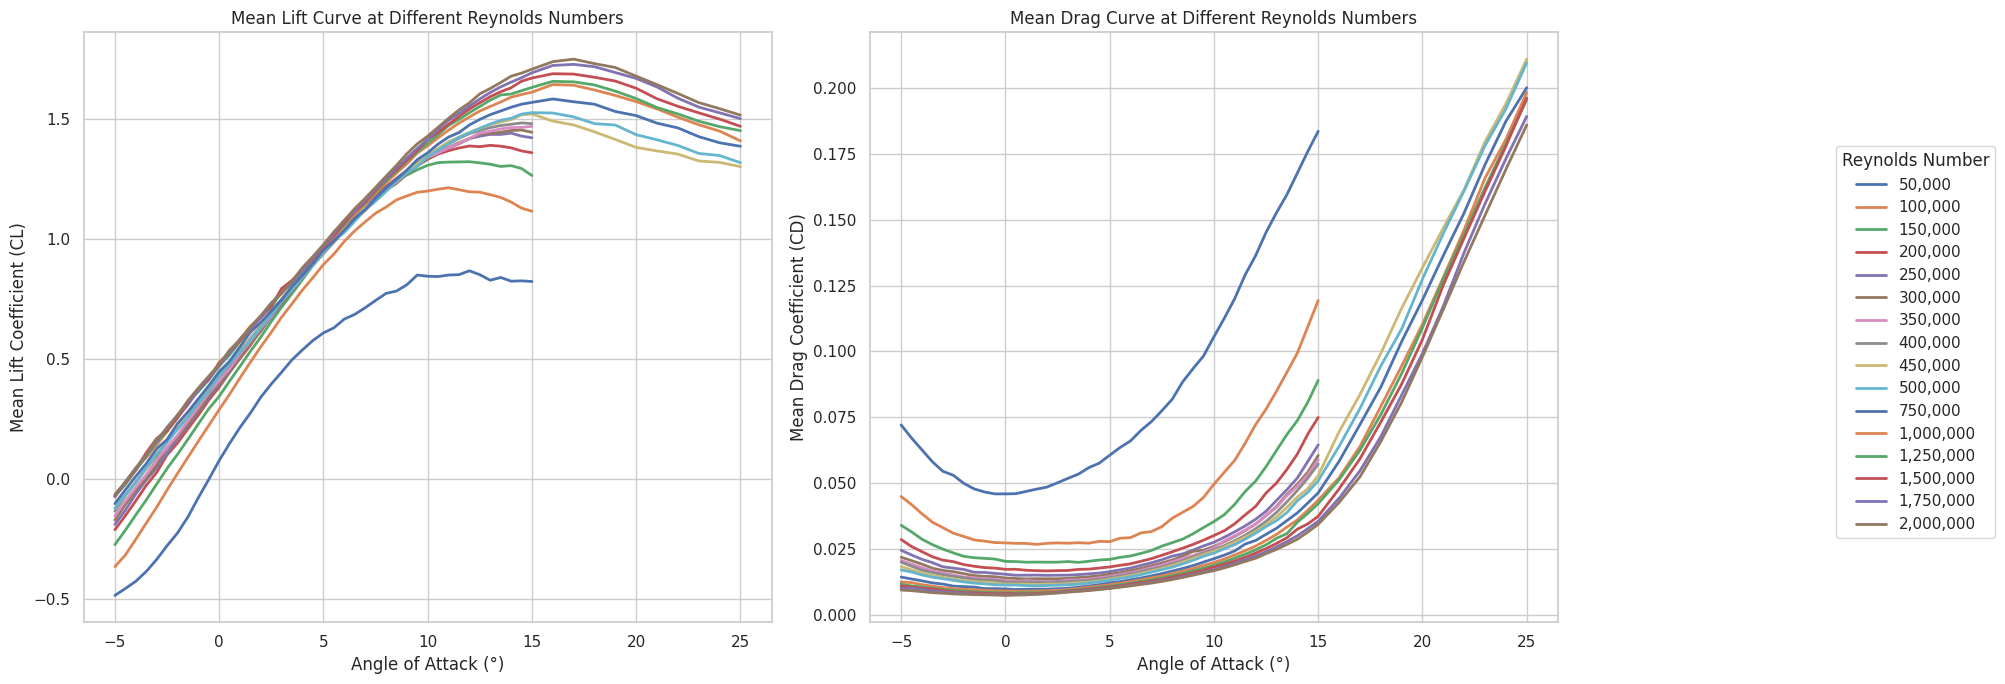

In [63]:
import matplotlib.pyplot as plt

# Unique Reynolds numbers
re_values = sorted(df["Re"].unique())

# Create subplot
fig, axs = plt.subplots(1, 2, figsize=(18, 7))

# ==========================================================
# CL vs Alpha
# ==========================================================

for Re in re_values:

    temp = (
        df[df["Re"] == Re]
        .groupby("Alpha")["CL"]
        .mean()
        .reset_index()
    )

    axs[0].plot(
        temp["Alpha"],
        temp["CL"],
        linewidth=2,
        label=f"{Re:,}"
    )

axs[0].set_title("Mean Lift Curve at Different Reynolds Numbers")
axs[0].set_xlabel("Angle of Attack (°)")
axs[0].set_ylabel("Mean Lift Coefficient (CL)")
axs[0].grid(True)

# ==========================================================
# CD vs Alpha
# ==========================================================

for Re in re_values:

    temp = (
        df[df["Re"] == Re]
        .groupby("Alpha")["CD"]
        .mean()
        .reset_index()
    )

    axs[1].plot(
        temp["Alpha"],
        temp["CD"],
        linewidth=2,
        label=f"{Re:,}"
    )

axs[1].set_title("Mean Drag Curve at Different Reynolds Numbers")
axs[1].set_xlabel("Angle of Attack (°)")
axs[1].set_ylabel("Mean Drag Coefficient (CD)")
axs[1].grid(True)

# ==========================================================
# Shared Legend
# ==========================================================

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Reynolds Number",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.88, 1])

plt.show()

Additional simulations in the range 15°–25° angle of attack were performed only for Reynolds numbers above 450,000, as lower Reynolds numbers already exhibited clear stall characteristics.

In [64]:
#Max cl values
df.nlargest(10, "CL")


,Camber,Position,Thickness,Re,Alpha,CL,CD,CDp,CM,TopXtr,BotXtr,L_D
412750,8,3,18,2000000,18.0,2.2286,0.04570,0.04183,-0.1130,0.2454,1.0,48.765864
412020,8,2,16,2000000,20.0,2.2191,0.06341,0.05964,-0.0866,0.1764,1.0,34.996057
412751,8,3,18,2000000,19.0,2.2164,0.05602,0.05225,-0.1082,0.2266,1.0,39.564441
412019,8,2,16,2000000,19.0,2.2143,0.05395,0.05007,-0.0877,0.1900,1.0,41.043559
412826,8,3,20,2000000,19.0,2.2118,0.05611,0.05244,-0.1082,0.2556,1.0,39.418998
412749,8,3,18,2000000,17.0,2.2117,0.03838,0.03442,-0.1173,0.2621,1.0,57.626368
412741,8,3,18,1750000,19.0,2.2084,0.05669,0.05294,-0.1075,0.2353,1.0,38.955724
412740,8,3,18,1750000,18.0,2.2078,0.04744,0.04352,-0.1114,0.2510,1.0,46.538786
407199,7,2,16,2000000,20.0,2.2046,0.05608,0.05231,-0.0724,0.1682,1.0,39.311698
412827,8,3,20,2000000,20.0,2.2015,0.06652,0.06301,-0.1048,0.2421,1.0,33.095310


In [65]:
#Max cd values
df.nlargest(10, "CD")

,Camber,Position,Thickness,Re,Alpha,CL,CD,CDp,CM,TopXtr,BotXtr,L_D
405252,6,7,8,1500000,25.0,1.4736,0.35913,0.35821,-0.2852,0.0023,1.0000,4.103250
395781,4,8,8,450000,25.0,1.4031,0.35734,0.35563,-0.2686,0.0056,1.0000,3.926513
410786,7,8,10,500000,25.0,1.5444,0.35493,0.35380,-0.3209,0.0091,1.0000,4.351281
399654,5,6,8,1750000,25.0,1.3765,0.35030,0.34931,-0.2434,0.0022,1.0000,3.929489
403980,6,5,8,1000000,25.0,1.3972,0.34778,0.34646,-0.2411,0.0031,1.0000,4.017482
415627,8,8,8,1750000,25.0,1.0247,0.34656,0.34596,-0.2258,0.0023,0.8075,2.956775
395780,4,8,8,450000,24.0,1.3751,0.34612,0.34440,-0.2588,0.0064,1.0000,3.972900
405251,6,7,8,1500000,24.0,1.4448,0.34578,0.34484,-0.2744,0.0023,1.0000,4.178379
415617,8,8,8,1500000,25.0,1.0238,0.34534,0.34472,-0.2251,0.0023,0.8132,2.964615
390148,3,7,8,500000,25.0,1.2864,0.34492,0.34296,-0.2186,0.0053,1.0000,3.729560


In [66]:
#Max L/D values
df.nlargest(10, "L_D")

,Camber,Position,Thickness,Re,Alpha,CL,CD,CDp,CM,TopXtr,BotXtr,L_D
315702,7,5,8,450000,3.5,1.2239,0.00103,-0.00353,-0.2031,0.7082,1.0,1188.252427
315701,7,5,8,450000,3.0,1.1731,0.00099,-0.00358,-0.2039,0.7230,1.0,1184.949495
315700,7,5,8,450000,2.5,1.1217,0.00095,-0.00363,-0.2045,0.7369,1.0,1180.736842
315703,7,5,8,450000,4.0,1.2741,0.00109,-0.00344,-0.2022,0.6920,1.0,1168.899083
201871,4,6,8,450000,3.0,0.8763,0.00075,-0.00307,-0.1388,0.7728,1.0,1168.400000
315699,7,5,8,450000,2.0,1.0697,0.00092,-0.00363,-0.2051,0.7503,1.0,1162.717391
315704,7,5,8,450000,4.5,1.3153,0.00114,-0.00343,-0.1992,0.6532,1.0,1153.771930
315698,7,5,8,450000,1.5,1.0174,0.00089,-0.00362,-0.2056,0.7633,1.0,1143.146067
201870,4,6,8,450000,2.5,0.8260,0.00073,-0.00300,-0.1405,0.8204,1.0,1131.506849
201872,4,6,8,450000,3.5,0.9203,0.00083,-0.00333,-0.1359,0.6738,1.0,1108.795181


In [67]:
df.nsmallest(10,"CD")

,Camber,Position,Thickness,Re,Alpha,CL,CD,CDp,CM,TopXtr,BotXtr,L_D
43801,1,1,8,500000,0.0,0.0988,0.00058,-0.00292,-0.0124,0.8321,0.9647,170.344828
43802,1,1,8,500000,0.5,0.1818,0.00058,-0.00323,-0.0177,0.7634,0.9928,313.448276
43800,1,1,8,500000,-0.5,0.0408,0.00059,-0.00280,-0.0131,0.8828,0.8927,69.152542
43803,1,1,8,500000,1.0,0.2495,0.00060,-0.00359,-0.0204,0.6777,1.0000,415.833333
43799,1,1,8,500000,-1.0,-0.0026,0.00064,-0.00313,-0.0173,0.9305,0.7340,-4.062500
43804,1,1,8,500000,1.5,0.2987,0.00065,-0.00393,-0.0194,0.5863,1.0000,459.538462
43805,1,1,8,500000,2.0,0.3471,0.00072,-0.00424,-0.0182,0.4944,1.0000,482.083333
201867,4,6,8,450000,1.0,0.6627,0.00073,-0.00291,-0.1424,0.8804,1.0000,907.808219
201868,4,6,8,450000,1.5,0.7187,0.00073,-0.00294,-0.1423,0.8683,1.0000,984.520548
201869,4,6,8,450000,2.0,0.7735,0.00073,-0.00294,-0.1418,0.8517,1.0000,1059.589041


In [68]:
df[df["CDp"] < 0]

,Camber,Position,Thickness,Re,Alpha,CL,CD,CDp,CM,TopXtr,BotXtr,L_D
43793,1,1,8,500000,-4.0,-0.3793,0.00368,-0.00206,-0.0062,1.0000,0.0219,-103.070652
43794,1,1,8,500000,-3.5,-0.3303,0.00249,-0.00341,-0.0050,0.9991,0.0240,-132.650602
43795,1,1,8,500000,-3.0,-0.2604,0.00167,-0.00433,-0.0084,0.9943,0.0288,-155.928144
43796,1,1,8,500000,-2.5,-0.1891,0.00143,-0.00463,-0.0119,0.9865,0.0350,-132.237762
43797,1,1,8,500000,-2.0,-0.1172,0.00119,-0.00490,-0.0156,0.9778,0.0482,-98.487395
...,...,...,...,...,...,...,...,...,...,...,...,...
346904,8,4,10,750000,7.5,1.5906,0.00210,-0.00288,-0.1750,0.4280,1.0000,757.428571
346905,8,4,10,750000,8.0,1.6245,0.00225,-0.00266,-0.1716,0.4114,1.0000,722.000000
346906,8,4,10,750000,8.5,1.6525,0.00251,-0.00239,-0.1674,0.3851,1.0000,658.366534
346907,8,4,10,750000,9.0,1.6698,0.00308,-0.00193,-0.1615,0.3437,1.0000,542.142857


# 9. Summary and Key Findings

This exploratory data analysis was conducted to validate the aerodynamic dataset generated using the automated XFOIL pipeline before developing a neural network surrogate model.

## Dataset Summary

- Initial dataset size: **599,869** aerodynamic operating points
- Duplicate records removed: **183,635**
- Final cleaned dataset: **416,234** unique operating points
- Missing values: **0**
- Airfoil family: **NACA 4-digit**
- Reynolds number range: **50,000 – 2,000,000**
- Angle of attack range: **−5° to 25°**

---

## Key Observations

### Data Quality

- No missing values were present in the dataset.
- Duplicate records introduced during dataset extension were successfully identified and removed.
- The cleaned dataset contains only unique aerodynamic operating points.

### Aerodynamic Validation

Representative airfoil analyses confirmed that the generated data follows expected aerodynamic behaviour, including:

- Linear lift increase in the pre-stall region.
- Reynolds-number-dependent stall characteristics.
- Post-stall lift degradation.
- Rapid drag increase after stall.
- Physically consistent pitching moment trends.
- Realistic transition point movement.

These observations indicate that the automated XFOIL pipeline successfully captured the expected aerodynamic characteristics.

### Statistical Analysis

The global distributions of the aerodynamic coefficients showed:

- Physically realistic coefficient ranges.
- Strong positive correlation between lift coefficient and angle of attack.
- Strong relationship between drag coefficient and pressure drag.
- Strong negative correlation between camber and pitching moment.
- No evidence of parser errors or unrealistic coefficient distributions.

### Outlier Investigation

Extreme values of lift, drag, and lift-to-drag ratio were manually inspected.

The observed extremes corresponded to physically meaningful operating conditions, primarily at high angles of attack or low drag operating points, rather than numerical errors.

Although a small number of negative pressure drag (CDp) values were observed, the total drag coefficient remained positive in all cases. Since pressure drag is not used as either an input feature or prediction target in the surrogate model, this variable will not be included during machine learning preprocessing.

---

## Conclusion

The dataset demonstrates good numerical integrity and physically consistent aerodynamic behaviour across the investigated design space.

The exploratory analysis provides confidence that the dataset is suitable for machine learning applications and accurately represents the aerodynamic trends expected from XFOIL simulations.

The dataset is therefore considered ready for preprocessing, feature scaling, and subsequent neural network training.